In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. Load data
df = pd.read_csv(r'C:\Users\User\Documents\GitHub\AIforBioinformatics\ignore_dir\dataset\transposed_GDS3257_add_target.csv', index_col=0)
df.dropna(axis=1, inplace=True)
X = df.drop(columns=['target'])
y = df['target'].map({'tumor': 1, 'normal': 0})

# 2. Split Data
X_train_full, X_test_full, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Row Outlier Removal
X_train_full = X_train_full.loc[:, X_train_full.var() > X_train_full.var().quantile(0.25)]
iso = IsolationForest(contamination=0.05, random_state=42) 
outlier_preds = iso.fit_predict(X_train_full)
X_train_cleaned = X_train_full[outlier_preds == 1]
y_train_cleaned = y_train_full[outlier_preds == 1]

# 4. Feature Quality Filtering (CV Quantile)
cv_scores = X_train_cleaned.std() / (X_train_cleaned.mean())
cv_threshold = cv_scores.quantile(0.95)
reliable_features = cv_scores[cv_scores < cv_threshold].index
X_train_reliable = X_train_cleaned[reliable_features]

# 5. Feature Selection (Top 400)
train_variances = X_train_reliable.var().sort_values(ascending=False)
top_400_features = train_variances.head(12).index

X_train_final = X_train_reliable[top_400_features]
X_test_final = X_test_full[top_400_features]

# 6. Train & Compare Linear Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC (Linear Kernel)": SVC(kernel='linear', random_state=42),
    "Perceptron (Single Node)": Perceptron(max_iter=1000, random_state=42)
}

print(f"Final features selected: {X_train_final.shape[1]}")
print("-" * 30)

for name, model in models.items():
    model.fit(X_train_final, y_train_cleaned)
    y_pred = model.predict(X_test_final)
    
    print(f"\nModel: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

Final features selected: 12
------------------------------

Model: Logistic Regression
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22


Model: SVC (Linear Kernel)
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22


Model: Perceptron (Single Node)
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00     

In [ ]:
X_train_full = X_train_full.loc[:, X_train_full.var() > X_train_full.var().quantile(0.25)]
iso = IsolationForest(contamination=0.05, random_state=42) 
outlier_preds = iso.fit_predict(X_train_full)
X_train_cleaned = X_train_full[outlier_preds == 1]
y_train_cleaned = y_train_full[outlier_preds == 1]

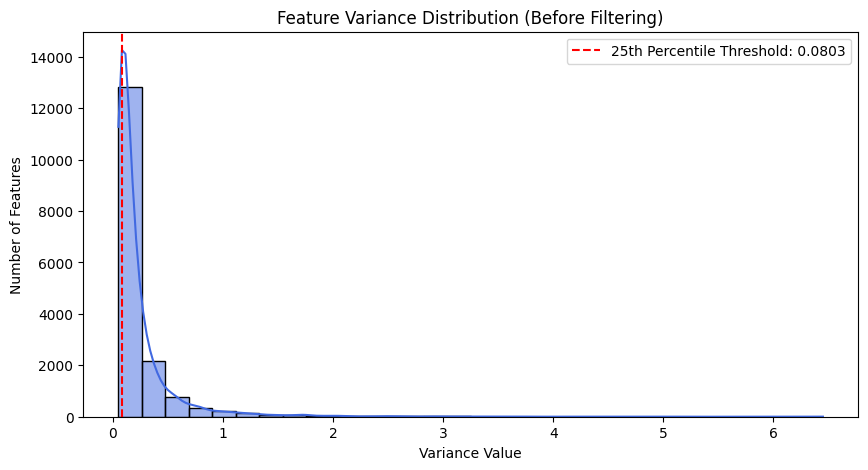

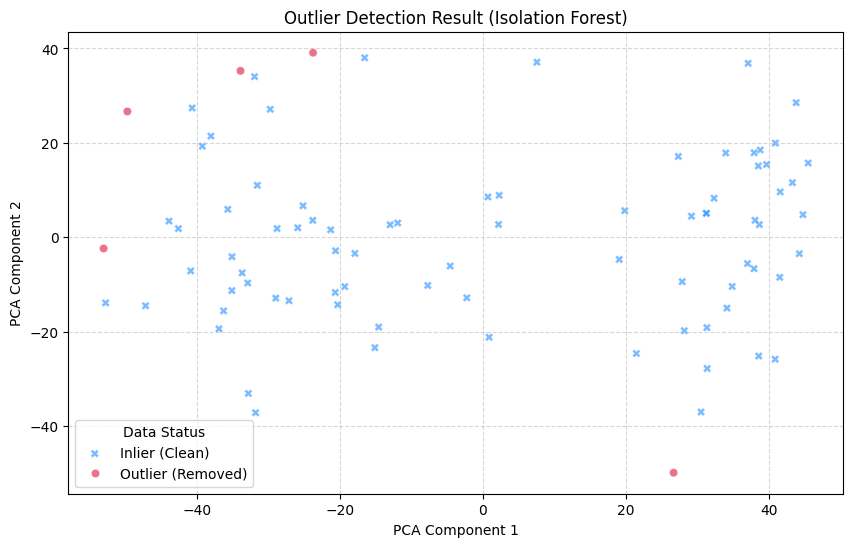

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# --- 1. Visualize Variance Filtering ---
variances = X_train_full.var()
var_threshold = variances.quantile(0.25)

plt.figure(figsize=(10, 5))
sns.histplot(variances, bins=30, kde=True, color='royalblue')
plt.axvline(var_threshold, color='red', linestyle='--', label=f'25th Percentile Threshold: {var_threshold:.4f}')
plt.title('Feature Variance Distribution (Before Filtering)')
plt.xlabel('Variance Value')
plt.ylabel('Number of Features')
plt.legend()
plt.show()

# --- 2. Visualize Outlier Removal (Using PCA) ---
# เราใช้ PCA เพื่อยุบมิติข้อมูลที่เหลืออยู่มาเป็น 2D เพื่อให้มองเห็นภาพ Outlier
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_full.loc[:, variances > var_threshold])

plt.figure(figsize=(10, 6))
# สร้าง Scatter plot โดยแยกสีตาม outlier_preds (1 คือ Inlier, -1 คือ Outlier)
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=outlier_preds, 
    palette={1: 'dodgerblue', -1: 'crimson'}, 
    alpha=0.6,
    style=outlier_preds
)

plt.title('Outlier Detection Result (Isolation Forest)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Data Status', labels=['Inlier (Clean)', 'Outlier (Removed)'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

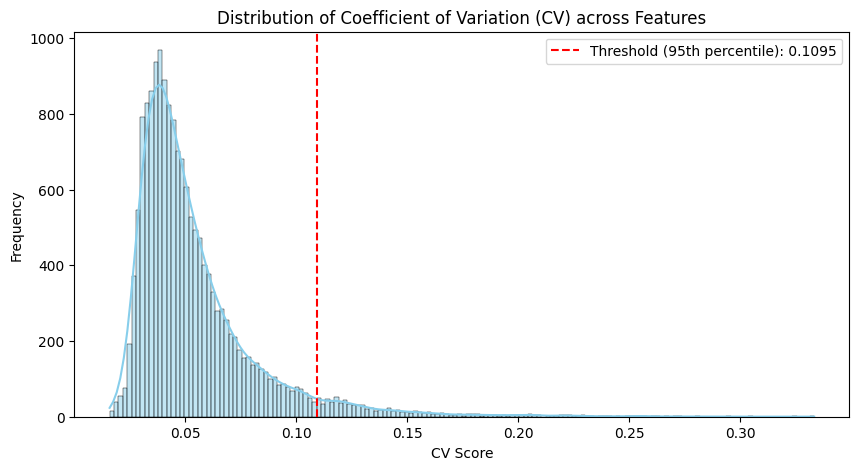

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(cv_scores, kde=True, color='skyblue')
plt.axvline(cv_threshold, color='red', linestyle='--', label=f'Threshold (95th percentile): {cv_threshold:.4f}')
plt.title('Distribution of Coefficient of Variation (CV) across Features')
plt.xlabel('CV Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_6944\1948962051.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_variances.values, y=top_variances.index, palette='viridis')


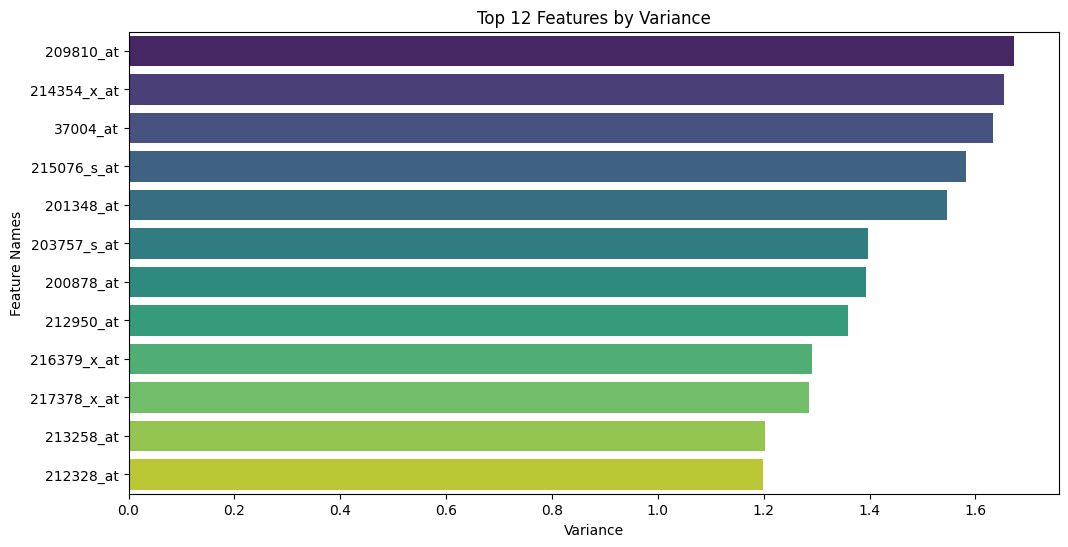

In [5]:
# 3. Visualize Top Features Variance
plt.figure(figsize=(12, 6))
top_variances = train_variances.head(12)
sns.barplot(x=top_variances.values, y=top_variances.index, palette='viridis')
plt.title('Top 12 Features by Variance')
plt.xlabel('Variance')
plt.ylabel('Feature Names')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Visualize Outliers
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_full)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=outlier_preds, palette={1: 'blue', -1: 'red'}, alpha=0.6)
plt.title('Outlier Detection (Isolation Forest) via PCA')
plt.legend(title='Is Inlier?', labels=['Outlier (-1)', 'Inlier (1)'])
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

Final features selected: 12
------------------------------

Model: Logistic Regression
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22


Model: SVC (Linear Kernel)
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22


Model: Perceptron (Single Node)
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00     

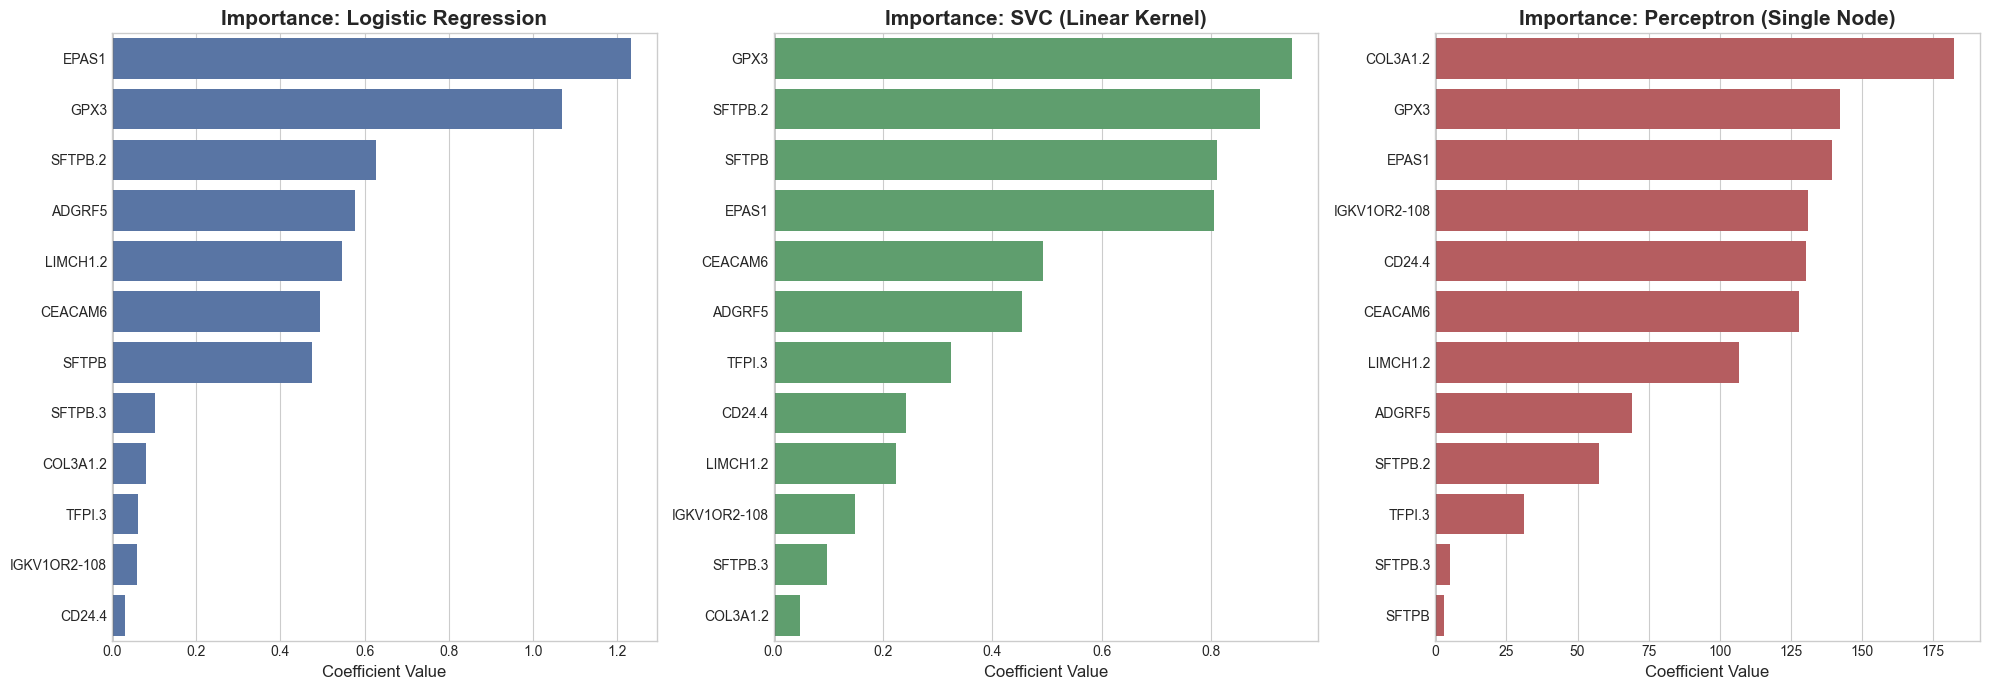

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. Load data
df = pd.read_csv(r'C:\Users\User\Documents\GitHub\AIforBioinformatics\new_target.csv', index_col=0)
df.dropna(axis=1, inplace=True)
X = df.drop(columns=['target'])
y = df['target'].map({'tumor': 1, 'normal': 0})

# 2. Split Data
X_train_full, X_test_full, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Row Outlier Removal
X_train_full = X_train_full.loc[:, X_train_full.var() > X_train_full.var().quantile(0.25)]
iso = IsolationForest(contamination=0.05, random_state=42) 
outlier_preds = iso.fit_predict(X_train_full)
X_train_cleaned = X_train_full[outlier_preds == 1]
y_train_cleaned = y_train_full[outlier_preds == 1]

# 4. Feature Quality Filtering (CV Quantile)
cv_scores = X_train_cleaned.std() / (X_train_cleaned.mean())
cv_threshold = cv_scores.quantile(0.95)
reliable_features = cv_scores[cv_scores < cv_threshold].index
X_train_reliable = X_train_cleaned[reliable_features]

# 5. Feature Selection (Top 400)
train_variances = X_train_reliable.var().sort_values(ascending=False)
top_400_features = train_variances.head(12).index

X_train_final = X_train_reliable[top_400_features]
X_test_final = X_test_full[top_400_features]

# 6. Train & Compare Linear Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC (Linear Kernel)": SVC(kernel='linear', random_state=42),
    "Perceptron (Single Node)": Perceptron(max_iter=1000, random_state=42)
}

print(f"Final features selected: {X_train_final.shape[1]}")
print("-" * 30)

for name, model in models.items():
    # ทุกโมเดลในกลุ่มนี้ใช้ข้อมูล Scaled
    model.fit(X_train_final, y_train_cleaned)
    y_pred = model.predict(X_test_final)
    
    print(f"\nModel: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))


# 1. เตรียมข้อมูล Importance (อิงจากโมเดลที่ถูก Train แล้วในขั้นตอนก่อนหน้า)
# ตรวจสอบว่าได้ทำ Scaling ข้อมูลก่อน Train หรือไม่ เพื่อให้ค่า Importance เปรียบเทียบกันได้ภายในโมเดล
models_to_plot = {
    "Logistic Regression": models["Logistic Regression"],
    "SVC (Linear Kernel)": models["SVC (Linear Kernel)"],
    "Perceptron (Single Node)": models["Perceptron (Single Node)"]
}

# 2. สร้าง Subplots 1 แถว 3 คอลัมน์
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = ['#4C72B0', '#55A868', '#C44E52'] # สีแยกแต่ละโมเดล

for i, (name, model) in enumerate(models_to_plot.items()):
    # ดึงค่า Coefficients
    coef_values = abs(model.coef_[0])
    features = top_400_features # รายชื่อยีน 12 ตัว
    
    # สร้าง DataFrame เฉพาะของโมเดลนั้นๆ และเรียงลำดับจากมากไปน้อย
    df_temp = pd.DataFrame({'Gene': features, 'Importance': coef_values})
    df_temp = df_temp.sort_values(by='Importance', ascending=False) # เรียงให้บวกอยู่บน
    
    # พล็อตกราฟแท่งแนวนอน
    sns.barplot(
        x='Importance', 
        y='Gene', 
        data=df_temp, 
        ax=axes[i], 
        color=colors[i]
    )
    
    # ตกแต่งกราฟ
    axes[i].set_title(f'Importance: {name}', fontsize=15, fontweight='bold')
    axes[i].axvline(x=0, color='black', linestyle='-', linewidth=1) # เส้นกลางที่ 0
    axes[i].set_xlabel('Coefficient Value', fontsize=12)
    axes[i].set_ylabel('') # ลบชื่อแกน Y ออกในรูปที่ 2 และ 3 เพื่อความสวยงาม
    # if i > 0:
    #     axes[i].set_yticklabels([]) # ซ่อนชื่อยีนในกราฟที่ 2 และ 3 เพราะเหมือนกัน

plt.tight_layout()
plt.show()

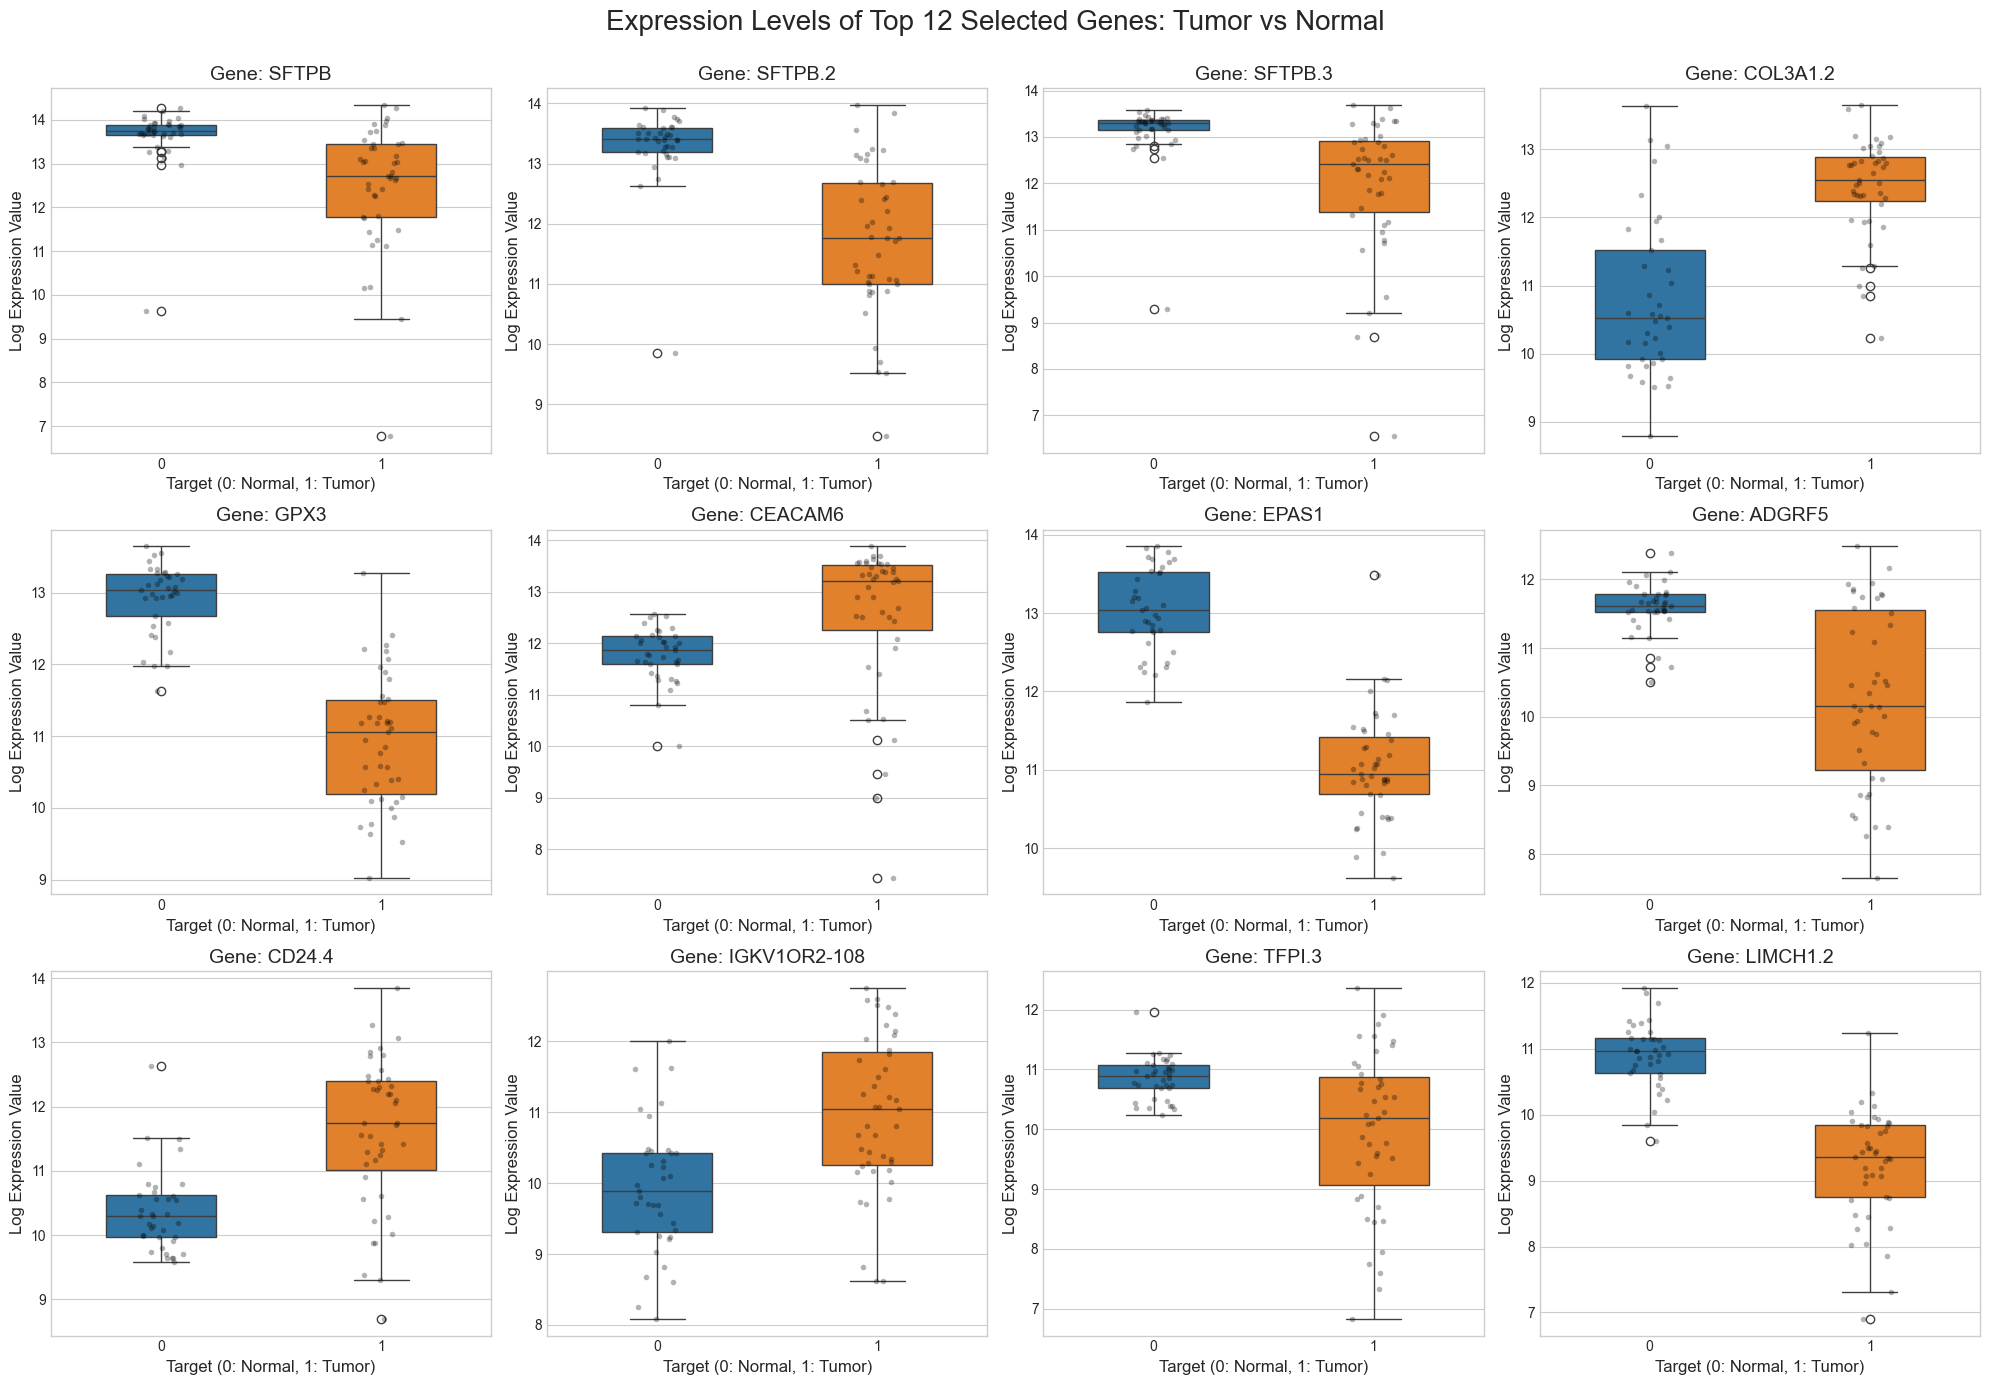

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
fig.suptitle('Expression Levels of Top 12 Selected Genes: Tumor vs Normal', fontsize=20, y=0.95)


genes_to_plot = top_400_features # ในโค้ดคุณคือ .head(12)


for i, gene in enumerate(genes_to_plot):
    row = i // 4
    col = i % 4


    sns.boxplot(x=y_train_cleaned, y=X_train_final[gene], ax=axes[row, col], hue=y_train_cleaned, legend=False, width=0.5) 
    sns.stripplot(x=y_train_cleaned, y=X_train_final[gene], ax=axes[row, col], color='black', alpha=0.3, size=4)

    axes[row, col].set_title(f'Gene: {gene}', fontsize=14)
    axes[row, col].set_xlabel('Target (0: Normal, 1: Tumor)', fontsize=12)
    axes[row, col].set_ylabel('Log Expression Value', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()